In [17]:
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt

model_path = "RobertoNeglia/pepe_generator"
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16
)
pipe.unet.load_attn_procs(model_path)
pipe.to("cuda")

prompt = "Pepe the frog holding a pint of beer, wearing a party hat, in a festive atmosphere, digital art style"

Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  8.10it/s]
/home/roberto/miniconda3/envs/genai/lib/python3.12/site-packages/diffusers/loaders/unet.py:212: FutureWarning: `load_attn_procs` is deprecated and will be removed in version 0.40.0. Using the `load_attn_procs()` method has been deprecated and will be removed in a future version. Please use `load_lora_adapter()`.
  deprecate("load_attn_procs", "0.40.0", deprecation_message)


Generating image 1...


 14%|█▍        | 7/50 [00:00<00:01, 31.10it/s]

100%|██████████| 50/50 [00:01<00:00, 34.22it/s]


Generating image 2...


100%|██████████| 50/50 [00:01<00:00, 34.16it/s]


Generating image 3...


100%|██████████| 50/50 [00:01<00:00, 33.42it/s]


Generating image 4...


100%|██████████| 50/50 [00:01<00:00, 34.14it/s]


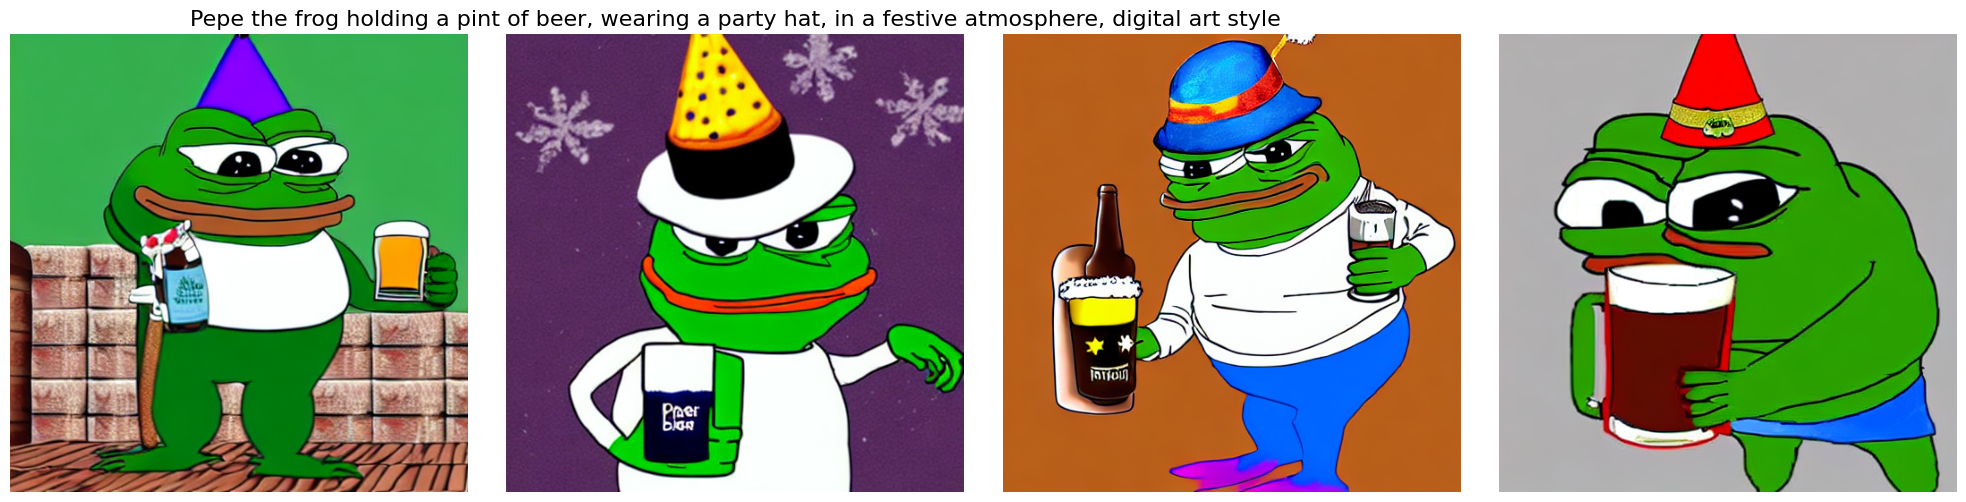

In [18]:
# image.save("pepe.png")
n_imagaes = 4
fig, ax = plt.subplots(1, n_imagaes, figsize=(20, 5))
for i in range(4):
    print(f"Generating image {i+1}...")
    with torch.no_grad():
        # Generate the image
        image = pipe(prompt, num_inference_steps=50, guidance_scale=7.5).images[0]
        ax[i].imshow(image)
        ax[i].axis("off")
ax[1].set_title(prompt, fontsize=16)
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.tight_layout()
plt.ion()  # Enable interactive mode for live updates